# Data Inspection

Initial inspection of the RSNA Pneumonia Detection Challenge dataset, including metadata structure, patient-level labels, annotation characteristics, and DICOM image properties.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_DIR = Path("...".resolve())
DATA_DIR = PROJECT_DIR / "rsna-pneumonia-detection-challenge"

TRAIN_IMAGE_DIR = DATA_DIR / "stage_2_train_images"
TEST_IMAGE_DIR = DATA_DIR / "stage_2_test_images"

TRAIN_LABELS_PATH = DATA_DIR / "stage_2_train_labels.csv"
CLASS_INFO_PATH = DATA_DIR / "stage_2_detailed_class_info.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "stage_2_sample_submission.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "data_inspection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Raw Dataset Inventory

Confirm the expected raw RSNA files are available and record their sizes/counts.


In [2]:
expected_paths = {
    "Training image directory": TRAIN_IMAGE_DIR,
    "Test image directory": TEST_IMAGE_DIR,
    "Training labels": TRAIN_LABELS_PATH,
    "Detailed class info": CLASS_INFO_PATH,
    "Sample submission": SAMPLE_SUBMISSION_PATH,
}

inventory = []
for name, path in expected_paths.items():
    inventory.append({
        "item": name,
        "path": str(path),
        "exists": path.exists(),
        "type": "directory" if path.is_dir() else "file",
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

if not inventory_df["exists"].all():
    missing = inventory_df.loc[~inventory_df["exists"], ["item", "path"]]
    raise FileNotFoundError(f"Missing expected dataset items:\n{missing.to_string(index=False)}")

print("All expected raw dataset items are available.")

,item,path,exists,type
0,Training image directory,E:\Projects\CNN and Vision Transformer-Based P...,True,directory
1,Test image directory,E:\Projects\CNN and Vision Transformer-Based P...,True,directory
2,Training labels,E:\Projects\CNN and Vision Transformer-Based P...,True,file
3,Detailed class info,E:\Projects\CNN and Vision Transformer-Based P...,True,file
4,Sample submission,E:\Projects\CNN and Vision Transformer-Based P...,True,file


All expected raw dataset items are available.


## 2. Load Metadata Tables

Load the three CSV files supplied with the Stage 2 dataset and inspect their dimensions and schemas.


In [3]:
labels_df = pd.read_csv(TRAIN_LABELS_PATH)
class_df = pd.read_csv(CLASS_INFO_PATH)
submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)

table_summary = pd.DataFrame({
    "table": [
        "stage_2_train_labels",
        "stage_2_detailed_class_info",
        "stage_2_sample_submission",
    ],
    "rows": [len(labels_df), len(class_df), len(submission_df)],
    "columns": [labels_df.shape[1], class_df.shape[1], submission_df.shape[1]],
})

display(table_summary)

print("\nTraining labels")
display(labels_df.head())

print("\nDetailed class information")
display(class_df.head())

print("\nSample submission")
display(submission_df.head())


,table,rows,columns
0,stage_2_train_labels,30227,6
1,stage_2_detailed_class_info,30227,2
2,stage_2_sample_submission,3000,2



Training labels


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1



Detailed class information


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity



Sample submission


,patientId,PredictionString
0,0000a175-0e68-4ca4-b1af-167204a7e0bc,0.5 0 0 100 100
1,0005d3cc-3c3f-40b9-93c3-46231c3eb813,0.5 0 0 100 100
2,000686d7-f4fc-448d-97a0-44fa9c5d3aa6,0.5 0 0 100 100
3,000e3a7d-c0ca-4349-bb26-5af2d8993c3d,0.5 0 0 100 100
4,00100a24-854d-423d-a092-edcf6179e061,0.5 0 0 100 100


## 3. Columns, Data Types, Missing Values, and Exact Duplicates

Inspect the raw tabular structure before any cleaning decisions are made.

Missing bounding-box coordinates are expected for images without a pneumonia opacity annotation; they are reported here without modification.


In [4]:
def dataframe_quality_summary(df, table_name):
    return pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_percentage": (df.isna().mean().values * 100),
        "unique_values": [df[col].nunique(dropna=True) for col in df.columns],
    })

quality_summary = pd.concat([
    dataframe_quality_summary(labels_df, "train_labels"),
    dataframe_quality_summary(class_df, "detailed_class_info"),
    dataframe_quality_summary(submission_df, "sample_submission"),
], ignore_index=True)

display(quality_summary)

duplicate_summary = pd.DataFrame({
    "table": ["train_labels", "detailed_class_info", "sample_submission"],
    "exact_duplicate_rows": [
        labels_df.duplicated().sum(),
        class_df.duplicated().sum(),
        submission_df.duplicated().sum(),
    ],
})

print("\nDuplicate rows")
display(duplicate_summary)


,table,column,dtype,missing_count,missing_percentage,unique_values
0,train_labels,patientId,object,0,0.000000,26684
1,train_labels,x,float64,20672,68.389188,748
2,train_labels,y,float64,20672,68.389188,726
3,train_labels,width,float64,20672,68.389188,351
4,train_labels,height,float64,20672,68.389188,725
5,train_labels,Target,int64,0,0.000000,2
6,detailed_class_info,patientId,object,0,0.000000,26684
7,detailed_class_info,class,object,0,0.000000,3
8,sample_submission,patientId,object,0,0.000000,3000
9,sample_submission,PredictionString,object,0,0.000000,1



Duplicate rows


,table,exact_duplicate_rows
0,train_labels,0
1,detailed_class_info,3543
2,sample_submission,0


## 4. Patient and Annotation Structure

The detection dataset can contain multiple annotation rows for one chest X-ray. This section quantifies unique patients and repeated annotation rows without collapsing or cleaning them.


In [5]:
annotation_counts = (
    labels_df.groupby("patientId")
    .size()
    .rename("annotation_rows")
    .reset_index()
)

patient_summary = pd.DataFrame({
    "metric": [
        "Label rows",
        "Unique labelled patients",
        "Repeated rows beyond one row per patient",
        "Patients with more than one annotation row",
        "Maximum annotation rows for one patient",
    ],
    "value": [
        len(labels_df),
        labels_df["patientId"].nunique(),
        len(labels_df) - labels_df["patientId"].nunique(),
        int((annotation_counts["annotation_rows"] > 1).sum()),
        int(annotation_counts["annotation_rows"].max()),
    ],
})

display(patient_summary)

print("\nAnnotation-row frequency")
annotation_frequency = (
    annotation_counts["annotation_rows"]
    .value_counts()
    .sort_index()
    .rename_axis("annotation_rows_per_patient")
    .reset_index(name="patient_count")
)
display(annotation_frequency)


,metric,value
0,Label rows,30227
1,Unique labelled patients,26684
2,Repeated rows beyond one row per patient,3543
3,Patients with more than one annotation row,3398
4,Maximum annotation rows for one patient,4



Annotation-row frequency


,annotation_rows_per_patient,patient_count
0,1,23286
1,2,3266
2,3,119
3,4,13


## 5. Binary Target Distribution

For inspection purposes, obtain one binary target per unique patient and examine the raw class imbalance.


In [6]:
patient_targets = (
    labels_df.groupby("patientId", as_index=False)["Target"]
    .max()
)

target_distribution = (
    patient_targets["Target"]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(patient_targets) * 100
)
target_distribution["label"] = target_distribution["Target"].map({
    0: "No Pneumonia",
    1: "Pneumonia",
})

display(target_distribution[["Target", "label", "count", "percentage"]])


,Target,label,count,percentage
0,0,No Pneumonia,20672,77.469645
1,1,Pneumonia,6012,22.530355


## 6. Diagnostic Classes and Target Relationship

Inspect the RSNA class labels and verify how they correspond to the binary target.


In [7]:
patient_classes = class_df.drop_duplicates(subset=["patientId"]).copy()

class_distribution = (
    patient_classes["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["percentage"] = ( 
    class_distribution["count"] / len(patient_classes) * 100
)

display(class_distribution)

target_class_df = patient_targets.merge(
    patient_classes,
    on="patientId",
    how="left",
    validate="one_to_one",
)

target_class_table = pd.crosstab(
    target_class_df["class"],
    target_class_df["Target"],
    margins=True,
)

print("\nClass vs binary target")
display(target_class_table)


,class,count,percentage
0,No Lung Opacity / Not Normal,11821,44.299955
1,Normal,8851,33.169690
2,Lung Opacity,6012,22.530355



Class vs binary target


Target,0,1,All
class,,,
Lung Opacity,0,6012,6012
No Lung Opacity / Not Normal,11821,0,11821
Normal,8851,0,8851
All,20672,6012,26684


## 7. Bounding-Box Annotation Summary

Inspect the raw pneumonia bounding-box annotations. This project is classification-focused, so bounding boxes are inspected here only to understand the source dataset.


In [8]:
positive_rows = labels_df[labels_df["Target"] == 1].copy()
negative_rows = labels_df[labels_df["Target"] == 0].copy()

bbox_summary = pd.DataFrame({
    "metric": [
        "Positive annotation rows",
        "Positive patients",
        "Negative rows",
        "Negative patients",
        "Positive rows missing any box coordinate",
        "Negative rows containing any box coordinate",
        "Positive rows with non-positive width/height",
    ],
    "value": [
        len(positive_rows),
        positive_rows["patientId"].nunique(),
        len(negative_rows),
        negative_rows["patientId"].nunique(),
        int(positive_rows[["x", "y", "width", "height"]].isna().any(axis=1).sum()),
        int(negative_rows[["x", "y", "width", "height"]].notna().any(axis=1).sum()),
        int(((positive_rows["width"] <= 0) | (positive_rows["height"] <= 0)).sum()),
    ],
})

display(bbox_summary)

print("\nBounding-box coordinate statistics")
bbox_describe = positive_rows[["x", "y", "width", "height"]].describe()
display(bbox_describe)


,metric,value
0,Positive annotation rows,9555
1,Positive patients,6012
2,Negative rows,20672
3,Negative patients,20672
4,Positive rows missing any box coordinate,0
5,Negative rows containing any box coordinate,0
6,Positive rows with non-positive width/height,0



Bounding-box coordinate statistics


,x,y,width,height
count,9555.000000,9555.000000,9555.000000,9555.000000
mean,394.047724,366.839560,218.471376,329.269702
std,204.574172,148.940488,59.289475,157.750755
min,2.000000,2.000000,40.000000,45.000000
25%,207.000000,249.000000,177.000000,203.000000
50%,324.000000,365.000000,217.000000,298.000000
75%,594.000000,478.500000,259.000000,438.000000
max,835.000000,881.000000,528.000000,942.000000


## 8. DICOM File Counts

Count the available raw training and competition-test DICOM files and compare the training image count with the number of unique labelled patients.


In [9]:
train_dicom_files = sorted(TRAIN_IMAGE_DIR.glob("*.dcm"))
test_dicom_files = sorted(TEST_IMAGE_DIR.glob("*.dcm"))

dicom_count_summary = pd.DataFrame({
    "metric": [
        "Training DICOM files",
        "Unique labelled patients",
        "Competition test DICOM files",
    ],
    "count": [
        len(train_dicom_files),
        labels_df["patientId"].nunique(),
        len(test_dicom_files),
    ],
})

display(dicom_count_summary)

,metric,count
0,Training DICOM files,26684
1,Unique labelled patients,26684
2,Competition test DICOM files,3000


## 9. Basic DICOM Structural Inspection

Read a small sample of training DICOM files to inspect image dimensions, pixel-array type, and selected acquisition metadata.

In [10]:
sample_files = train_dicom_files[:20]

dicom_records = []

for path in sample_files:
    ds = pydicom.dcmread(path)
    pixels = ds.pixel_array

    dicom_records.append({
        "patientId": path.stem,
        "rows": int(ds.Rows),
        "columns": int(ds.Columns),
        "pixel_dtype": str(pixels.dtype),
        "pixel_min": float(np.min(pixels)),
        "pixel_max": float(np.max(pixels)),
        "photometric_interpretation": getattr(ds, "PhotometricInterpretation", None),
        "bits_stored": getattr(ds, "BitsStored", None),
    })

dicom_sample_df = pd.DataFrame(dicom_records)
display(dicom_sample_df)

print("\nSample dimension frequencies")
display(
    dicom_sample_df[["rows", "columns"]]
    .value_counts()
    .rename("count")
    .reset_index()
)


,patientId,rows,columns,pixel_dtype,pixel_min,pixel_max,photometric_interpretation,bits_stored
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,1024,1024,uint8,0.0,245.0,MONOCHROME2,8
1,000924cf-0f8d-42bd-9158-1af53881a557,1024,1024,uint8,0.0,255.0,MONOCHROME2,8
2,000db696-cf54-4385-b10b-6b16fbb3f985,1024,1024,uint8,0.0,209.0,MONOCHROME2,8
3,000fe35a-2649-43d4-b027-e67796d412e0,1024,1024,uint8,0.0,233.0,MONOCHROME2,8
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1024,1024,uint8,0.0,232.0,MONOCHROME2,8
5,0010f549-b242-4e94-87a8-57d79de215fc,1024,1024,uint8,0.0,179.0,MONOCHROME2,8
6,001916b8-3d30-4935-a5d1-8eaddb1646cd,1024,1024,uint8,0.0,255.0,MONOCHROME2,8
7,0022073f-cec8-42ec-ab5f-bc2314649235,1024,1024,uint8,0.0,255.0,MONOCHROME2,8
8,0022995a-45eb-4cfa-9a59-cd15f5196c64,1024,1024,uint8,0.0,255.0,MONOCHROME2,8
9,0025d2de-bd78-4d36-9f72-e15a5e22ca82,1024,1024,uint8,8.0,235.0,MONOCHROME2,8



Sample dimension frequencies


,rows,columns,count
0,1024,1024,20


## 10. Raw Image Examples

Display a few raw DICOM chest X-rays from both target classes. Bounding boxes are overlaid on positive examples only to illustrate the original RSNA annotations.


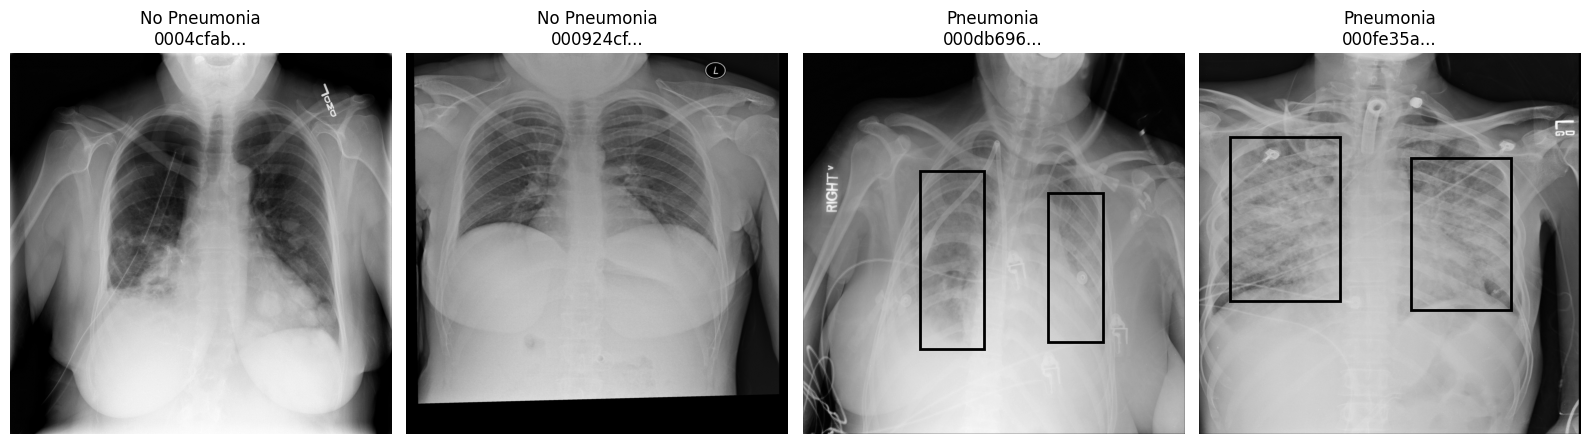

In [11]:
negative_ids = patient_targets.loc[
    patient_targets["Target"] == 0, "patientId"
].head(2).tolist()

positive_ids = patient_targets.loc[
    patient_targets["Target"] == 1, "patientId"
].head(2).tolist()

example_ids = negative_ids + positive_ids

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, patient_id in zip(axes, example_ids):
    image_path = TRAIN_IMAGE_DIR / f"{patient_id}.dcm"
    ds = pydicom.dcmread(image_path)
    image = ds.pixel_array

    target = int(
        patient_targets.loc[
            patient_targets["patientId"] == patient_id, "Target"
        ].iloc[0]
    )

    ax.imshow(image, cmap="gray")

    if target == 1:
        boxes = labels_df[
            (labels_df["patientId"] == patient_id) &
            (labels_df["Target"] == 1)
        ]

        for _, row in boxes.iterrows():
            rectangle = plt.Rectangle(
                (row["x"], row["y"]),
                row["width"],
                row["height"],
                fill=False,
                linewidth=2,
            )
            ax.add_patch(rectangle)

    ax.set_title(
        f"{'Pneumonia' if target == 1 else 'No Pneumonia'}\n{patient_id[:8]}..."
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "raw_image_examples.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 11. Inspection Summary

Summary of the main dataset characteristics identified during raw data inspection.


In [12]:
inspection_summary = pd.DataFrame({
    "metric": [
        "Raw label rows",
        "Unique labelled patients",
        "Pneumonia patients",
        "Non-pneumonia patients",
        "Training DICOM files",
        "Competition test DICOM files",
        "Detailed diagnostic classes",
        "Exact duplicate label rows",
    ],
    "value": [
        len(labels_df),
        labels_df["patientId"].nunique(),
        int((patient_targets["Target"] == 1).sum()),
        int((patient_targets["Target"] == 0).sum()),
        len(train_dicom_files),
        len(test_dicom_files),
        patient_classes["class"].nunique(),
        int(labels_df.duplicated().sum()),
    ],
})

display(inspection_summary)

print("\nDATA INSPECTION COMPLETE")


,metric,value
0,Raw label rows,30227
1,Unique labelled patients,26684
2,Pneumonia patients,6012
3,Non-pneumonia patients,20672
4,Training DICOM files,26684
5,Competition test DICOM files,3000
6,Detailed diagnostic classes,3
7,Exact duplicate label rows,0



DATA INSPECTION COMPLETE
